# Notebook 1 - ETL & Data Engineering

**Project phase:** Formula 1 Big Data Analysis with PySpark  
**Spark components:** RDDs, DataFrames, SparkSQL  
**Goal:** Ingest the 14 raw Formula 1 CSV files into a medallion architecture and create clean analytical-ready Gold tables.

The dataset is compiled from the Ergast Formula 1 database and covers races, drivers, constructors, circuits, qualifying, lap times, pit stops, standings, sprint results, and race statuses from 1950 through 2024.

## Big-Data Engineering Principles Used

- Explicit schemas are used for all CSV ingestion. We avoid `inferSchema=True` because schema inference requires extra scans and can be unsafe at scale.
- Parquet is used for lakehouse storage because it is columnar, compressed, and efficient for analytical queries.
- Gold tables are partitioned by `year` where applicable to improve pruning for time-based analysis.
- Small dimension tables are joined with `broadcast()` where suitable.
- Python-native `sorted()` and pre-aggregation `.collect()` are avoided. Ordering and aggregation are handled by Spark.
- RDD logic is included for pedagogical completeness, but DataFrames and SparkSQL are preferred for production because Catalyst and Tungsten optimize query planning and execution.

## Google Colab Setup

Run this cell first in Google Colab. It installs the required libraries and mounts Google Drive. The raw CSV files are expected to be available at `DATASET_PATH = "/content/drive/MyDrive/Dataset"`.

In [ ]:
#!pip install -q pyspark pandas numpy matplotlib seaborn pyarrow

from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = "/content/drive/MyDrive/data_analysis"

Mounted at /content/drive


In [ ]:
import os

import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.sql.window import Window
from pyspark.sql.functions import broadcast
from pyspark.ml.feature import Imputer

spark = (
    SparkSession.builder
    .appName("F1 Notebook 1 - ETL and Data Engineering")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.sources.partitionOverwriteMode", "dynamic")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
spark

In [ ]:
RAW_PATH = DATASET_PATH
BRONZE_PATH = "/content/lakehouse/bronze"
SILVER_PATH = "/content/lakehouse/silver"
GOLD_PATH = "/content/lakehouse/gold"

if not os.path.exists(RAW_PATH):
    raise FileNotFoundError(f"Dataset folder not found: {RAW_PATH}. Mount Google Drive and confirm the CSV files are in this folder.")

CSV_OPTIONS = {
    "header": "true",
    "quote": '"',
    "escape": '"',
    "nullValue": "\\N",
    "mode": "PERMISSIVE"
}

def read_csv_with_schema(file_name: str, schema: T.StructType):
    return (
        spark.read
        .options(**CSV_OPTIONS)
        .schema(schema)
        .csv(f"{RAW_PATH}/{file_name}")
        .withColumn("ingested_at", F.current_timestamp())
        .withColumn("source_file", F.lit(file_name))
    )

def write_parquet(df, path: str, partition_cols=None):
    writer = df.write.mode("overwrite").format("parquet")
    if partition_cols:
        writer = writer.partitionBy(*partition_cols)
    writer.save(path)

## Bronze Layer - Explicit Schema Ingestion

The Bronze layer keeps the raw business meaning of the source files while converting them to Parquet and adding audit columns. These tables are intentionally close to the source so downstream transformations remain traceable.

In [ ]:
schemas = {
    "circuits.csv": T.StructType([
        T.StructField("circuitId", T.IntegerType()), T.StructField("circuitRef", T.StringType()),
        T.StructField("name", T.StringType()), T.StructField("location", T.StringType()),
        T.StructField("country", T.StringType()), T.StructField("lat", T.DoubleType()),
        T.StructField("lng", T.DoubleType()), T.StructField("alt", T.IntegerType()),
        T.StructField("url", T.StringType())]),
    "constructor_results.csv": T.StructType([
        T.StructField("constructorResultsId", T.IntegerType()), T.StructField("raceId", T.IntegerType()),
        T.StructField("constructorId", T.IntegerType()), T.StructField("points", T.DoubleType()),
        T.StructField("status", T.StringType())]),
    "constructor_standings.csv": T.StructType([
        T.StructField("constructorStandingsId", T.IntegerType()), T.StructField("raceId", T.IntegerType()),
        T.StructField("constructorId", T.IntegerType()), T.StructField("points", T.DoubleType()),
        T.StructField("position", T.IntegerType()), T.StructField("positionText", T.StringType()),
        T.StructField("wins", T.IntegerType())]),
    "constructors.csv": T.StructType([
        T.StructField("constructorId", T.IntegerType()), T.StructField("constructorRef", T.StringType()),
        T.StructField("name", T.StringType()), T.StructField("nationality", T.StringType()),
        T.StructField("url", T.StringType())]),
    "driver_standings.csv": T.StructType([
        T.StructField("driverStandingsId", T.IntegerType()), T.StructField("raceId", T.IntegerType()),
        T.StructField("driverId", T.IntegerType()), T.StructField("points", T.DoubleType()),
        T.StructField("position", T.IntegerType()), T.StructField("positionText", T.StringType()),
        T.StructField("wins", T.IntegerType())]),
    "drivers.csv": T.StructType([
        T.StructField("driverId", T.IntegerType()), T.StructField("driverRef", T.StringType()),
        T.StructField("number", T.IntegerType()), T.StructField("code", T.StringType()),
        T.StructField("forename", T.StringType()), T.StructField("surname", T.StringType()),
        T.StructField("dob", T.DateType()), T.StructField("nationality", T.StringType()),
        T.StructField("url", T.StringType())]),
    "lap_times.csv": T.StructType([
        T.StructField("raceId", T.IntegerType()), T.StructField("driverId", T.IntegerType()),
        T.StructField("lap", T.IntegerType()), T.StructField("position", T.IntegerType()),
        T.StructField("time", T.StringType()), T.StructField("milliseconds", T.IntegerType())]),
    "pit_stops.csv": T.StructType([
        T.StructField("raceId", T.IntegerType()), T.StructField("driverId", T.IntegerType()),
        T.StructField("stop", T.IntegerType()), T.StructField("lap", T.IntegerType()),
        T.StructField("time", T.StringType()), T.StructField("duration", T.StringType()),
        T.StructField("milliseconds", T.IntegerType())]),
    "qualifying.csv": T.StructType([
        T.StructField("qualifyId", T.IntegerType()), T.StructField("raceId", T.IntegerType()),
        T.StructField("driverId", T.IntegerType()), T.StructField("constructorId", T.IntegerType()),
        T.StructField("number", T.IntegerType()), T.StructField("position", T.IntegerType()),
        T.StructField("q1", T.StringType()), T.StructField("q2", T.StringType()), T.StructField("q3", T.StringType())]),
    "races.csv": T.StructType([
        T.StructField("raceId", T.IntegerType()), T.StructField("year", T.IntegerType()),
        T.StructField("round", T.IntegerType()), T.StructField("circuitId", T.IntegerType()),
        T.StructField("name", T.StringType()), T.StructField("date", T.DateType()),
        T.StructField("time", T.StringType()), T.StructField("url", T.StringType()),
        T.StructField("fp1_date", T.DateType()), T.StructField("fp1_time", T.StringType()),
        T.StructField("fp2_date", T.DateType()), T.StructField("fp2_time", T.StringType()),
        T.StructField("fp3_date", T.DateType()), T.StructField("fp3_time", T.StringType()),
        T.StructField("quali_date", T.DateType()), T.StructField("quali_time", T.StringType()),
        T.StructField("sprint_date", T.DateType()), T.StructField("sprint_time", T.StringType())]),
    "results.csv": T.StructType([
        T.StructField("resultId", T.IntegerType()), T.StructField("raceId", T.IntegerType()),
        T.StructField("driverId", T.IntegerType()), T.StructField("constructorId", T.IntegerType()),
        T.StructField("number", T.IntegerType()), T.StructField("grid", T.IntegerType()),
        T.StructField("position", T.IntegerType()), T.StructField("positionText", T.StringType()),
        T.StructField("positionOrder", T.IntegerType()), T.StructField("points", T.DoubleType()),
        T.StructField("laps", T.IntegerType()), T.StructField("time", T.StringType()),
        T.StructField("milliseconds", T.IntegerType()), T.StructField("fastestLap", T.IntegerType()),
        T.StructField("rank", T.IntegerType()), T.StructField("fastestLapTime", T.StringType()),
        T.StructField("fastestLapSpeed", T.DoubleType()), T.StructField("statusId", T.IntegerType())]),
    "seasons.csv": T.StructType([T.StructField("year", T.IntegerType()), T.StructField("url", T.StringType())]),
    "sprint_results.csv": T.StructType([
        T.StructField("resultId", T.IntegerType()), T.StructField("raceId", T.IntegerType()),
        T.StructField("driverId", T.IntegerType()), T.StructField("constructorId", T.IntegerType()),
        T.StructField("number", T.IntegerType()), T.StructField("grid", T.IntegerType()),
        T.StructField("position", T.IntegerType()), T.StructField("positionText", T.StringType()),
        T.StructField("positionOrder", T.IntegerType()), T.StructField("points", T.DoubleType()),
        T.StructField("laps", T.IntegerType()), T.StructField("time", T.StringType()),
        T.StructField("milliseconds", T.IntegerType()), T.StructField("fastestLap", T.IntegerType()),
        T.StructField("fastestLapTime", T.StringType()), T.StructField("statusId", T.IntegerType())]),
    "status.csv": T.StructType([T.StructField("statusId", T.IntegerType()), T.StructField("status", T.StringType())])
}

In [ ]:
bronze = {file_name.replace(".csv", ""): read_csv_with_schema(file_name, schema)
          for file_name, schema in schemas.items()}

for table_name, df in bronze.items():
    if table_name in {"races", "seasons"}:
        write_parquet(df, f"{BRONZE_PATH}/{table_name}", ["year"])
    elif "raceId" in df.columns:
        write_parquet(df, f"{BRONZE_PATH}/{table_name}", ["raceId"])
    else:
        write_parquet(df, f"{BRONZE_PATH}/{table_name}")

bronze_counts = [(name, df.count()) for name, df in bronze.items()]
spark.createDataFrame(bronze_counts, ["table", "row_count"]).orderBy("table").show(50, truncate=False)

+---------------------+---------+
|table                |row_count|
+---------------------+---------+
|circuits             |77       |
|constructor_results  |12625    |
|constructor_standings|13391    |
|constructors         |212      |
|driver_standings     |34863    |
|drivers              |861      |
|lap_times            |589081   |
|pit_stops            |11371    |
|qualifying           |10494    |
|races                |1125     |
|results              |26759    |
|seasons              |75       |
|sprint_results       |360      |
|status               |139      |
+---------------------+---------+



## Silver Layer - Cleaning, Conformance, and Validation

The Silver layer standardizes columns, handles missing values, normalizes time strings into integer milliseconds, validates joins, and keeps audit columns from ingestion.

In [ ]:
def lap_time_to_ms(col_name: str):
    c = F.col(col_name)
    minutes = F.regexp_extract(c, r"^(\\d+):", 1).cast("int")
    seconds = F.regexp_extract(c, r":(\\d+)\\.", 1).cast("int")
    millis = F.regexp_extract(c, r"\\.(\\d+)$", 1).cast("int")
    return F.when(c.rlike(r"^\\d+:\\d{2}\\.\\d{3}$"), minutes * 60000 + seconds * 1000 + millis)

def race_time_to_ms(col_name: str):
    c = F.col(col_name)
    hours = F.regexp_extract(c, r"^(\\d+):\\d{2}:", 1).cast("int")
    minutes = F.regexp_extract(c, r"^\\d+:(\\d{2}):", 1).cast("int")
    seconds = F.regexp_extract(c, r":(\\d{2})\\.", 1).cast("int")
    millis = F.regexp_extract(c, r"\\.(\\d+)$", 1).cast("int")
    return F.when(c.rlike(r"^\\d+:\\d{2}:\\d{2}\\.\\d{3}$"), hours * 3600000 + minutes * 60000 + seconds * 1000 + millis)

def add_missing_flags(df, columns):
    for column in columns:
        df = df.withColumn(f"{column}_was_missing", F.col(column).isNull())
    return df

In [ ]:
races = bronze["races"].select("raceId", "year", "round", "circuitId", F.col("name").alias("race_name"), "date", "ingested_at", "source_file")
drivers = bronze["drivers"].withColumn("driver_name", F.concat_ws(" ", "forename", "surname"))
constructors = bronze["constructors"].withColumnRenamed("name", "constructor_name")
circuits = bronze["circuits"].withColumnRenamed("name", "circuit_name")
status = bronze["status"]

results = (
    bronze["results"]
    .transform(lambda df: add_missing_flags(df, ["position", "time", "milliseconds", "fastestLap", "rank", "fastestLapTime", "fastestLapSpeed"]))
    .withColumn("race_duration_ms", F.coalesce(F.col("milliseconds"), race_time_to_ms("time")))
    .withColumn("fastest_lap_ms", lap_time_to_ms("fastestLapTime"))
    .withColumn("position", F.coalesce(F.col("position"), F.col("positionOrder")))
)

qualifying = (
    bronze["qualifying"]
    .transform(lambda df: add_missing_flags(df, ["q1", "q2", "q3"]))
    .withColumn("q1_ms", lap_time_to_ms("q1"))
    .withColumn("q2_ms", lap_time_to_ms("q2"))
    .withColumn("q3_ms", lap_time_to_ms("q3"))
    .withColumn("best_qualifying_ms", F.least("q1_ms", "q2_ms", "q3_ms"))
)

lap_times = (
    bronze["lap_times"]
    .transform(lambda df: add_missing_flags(df, ["time", "milliseconds"]))
    .withColumn("lap_time_ms", F.coalesce(F.col("milliseconds"), lap_time_to_ms("time")))
    .filter(F.col("lap_time_ms").isNotNull())
)

pit_stops = bronze["pit_stops"].withColumnRenamed("milliseconds", "pit_stop_ms")
driver_standings = bronze["driver_standings"]
constructor_standings = bronze["constructor_standings"]

In [ ]:
silver = {
    "races": races,
    "drivers": drivers,
    "constructors": constructors,
    "circuits": circuits,
    "status": status,
    "results": results,
    "qualifying": qualifying,
    "lap_times": lap_times,
    "pit_stops": pit_stops,
    "driver_standings": driver_standings,
    "constructor_standings": constructor_standings,
    "constructor_results": bronze["constructor_results"],
    "seasons": bronze["seasons"],
    "sprint_results": bronze["sprint_results"]
}

for table_name, df in silver.items():
    df_to_write = df
    if "raceId" in df.columns and "year" not in df.columns:
        df_to_write = df.join(broadcast(races.select("raceId", "year")), "raceId", "left")
    if "year" in df_to_write.columns:
        write_parquet(df_to_write, f"{SILVER_PATH}/{table_name}", ["year"])
    else:
        write_parquet(df_to_write, f"{SILVER_PATH}/{table_name}")

spark.createDataFrame([(k, v.count()) for k, v in silver.items()], ["table", "row_count"]).orderBy("table").show(50, truncate=False)

+---------------------+---------+
|table                |row_count|
+---------------------+---------+
|circuits             |77       |
|constructor_results  |12625    |
|constructor_standings|13391    |
|constructors         |212      |
|driver_standings     |34863    |
|drivers              |861      |
|lap_times            |589081   |
|pit_stops            |11371    |
|qualifying           |10494    |
|races                |1125     |
|results              |26759    |
|seasons              |75       |
|sprint_results       |360      |
|status               |139      |
+---------------------+---------+



### Referential Integrity Checks

These checks identify orphan keys before Gold tables are produced. In a production pipeline, failed checks could stop the job or write rejected rows to a quarantine area.

In [ ]:
integrity_checks = []

integrity_checks.append((
    "results_without_race",
    results.join(races.select("raceId"), "raceId", "left_anti").count()
))
integrity_checks.append((
    "results_without_driver",
    results.join(drivers.select("driverId"), "driverId", "left_anti").count()
))
integrity_checks.append((
    "results_without_constructor",
    results.join(constructors.select("constructorId"), "constructorId", "left_anti").count()
))
integrity_checks.append((
    "qualifying_without_result_key",
    qualifying.join(results.select("raceId", "driverId").distinct(), ["raceId", "driverId"], "left_anti").count()
))

spark.createDataFrame(integrity_checks, ["check", "failed_rows"]).orderBy("check").show(truncate=False)

+-----------------------------+-----------+
|check                        |failed_rows|
+-----------------------------+-----------+
|qualifying_without_result_key|0          |
|results_without_constructor  |0          |
|results_without_driver       |0          |
|results_without_race         |0          |
+-----------------------------+-----------+



## Gold Layer - Analytical Tables

Gold tables are curated for analysis. They combine facts and dimensions into stable business entities that can be used by later notebooks for visualization, machine learning, and graph analytics.

In [ ]:
pit_summary = (
    pit_stops.groupBy("raceId", "driverId")
    .agg(
        F.count("stop").alias("pit_stop_count"),
        F.sum("pit_stop_ms").alias("total_pit_stop_ms"),
        F.avg("pit_stop_ms").alias("avg_pit_stop_ms")
    )
)

fact_race_result = (
    results.alias("res")
    .join(broadcast(races).alias("rac"), "raceId", "left")
    .join(qualifying.select("raceId", "driverId", F.col("position").alias("qualifying_position"), "q1_ms", "q2_ms", "q3_ms", "best_qualifying_ms"), ["raceId", "driverId"], "left")
    .join(driver_standings.select("raceId", "driverId", F.col("points").alias("driver_championship_points"), F.col("position").alias("driver_championship_position"), F.col("wins").alias("driver_wins_to_date")), ["raceId", "driverId"], "left")
    .join(constructor_standings.select("raceId", "constructorId", F.col("points").alias("constructor_championship_points"), F.col("position").alias("constructor_championship_position"), F.col("wins").alias("constructor_wins_to_date")), ["raceId", "constructorId"], "left")
    .join(pit_summary, ["raceId", "driverId"], "left")
    .join(broadcast(status.select("statusId", "status")).alias("stat"), "statusId", "left")
    .select(
        "raceId", "year", "round", "race_name", "date", "circuitId",
        "driverId", "constructorId", "grid", "position", "positionOrder", "points", "laps",
        "race_duration_ms", "fastestLap", "fastest_lap_ms", "fastestLapSpeed", "statusId", "status",
        "qualifying_position", "q1_ms", "q2_ms", "q3_ms", "best_qualifying_ms",
        "driver_championship_points", "driver_championship_position", "driver_wins_to_date",
        "constructor_championship_points", "constructor_championship_position", "constructor_wins_to_date",
        F.coalesce("pit_stop_count", F.lit(0)).alias("pit_stop_count"),
        "total_pit_stop_ms", "avg_pit_stop_ms",
        "position_was_missing", "time_was_missing", "milliseconds_was_missing"
    )
)

write_parquet(fact_race_result, f"{GOLD_PATH}/fact_race_result", ["year"])
fact_race_result.orderBy("year", "round", "positionOrder").show(20, truncate=False)

+------+----+-----+------------------+----------+---------+--------+-------------+----+--------+-------------+------+----+----------------+----------+--------------+---------------+--------+--------------+-------------------+-----+-----+-----+------------------+--------------------------+----------------------------+-------------------+-------------------------------+---------------------------------+------------------------+--------------+-----------------+---------------+--------------------+----------------+------------------------+
|raceId|year|round|race_name         |date      |circuitId|driverId|constructorId|grid|position|positionOrder|points|laps|race_duration_ms|fastestLap|fastest_lap_ms|fastestLapSpeed|statusId|status        |qualifying_position|q1_ms|q2_ms|q3_ms|best_qualifying_ms|driver_championship_points|driver_championship_position|driver_wins_to_date|constructor_championship_points|constructor_championship_position|constructor_wins_to_date|pit_stop_count|total_pit_stop

In [ ]:
driver_career = (
    results.join(races.select("raceId", "year"), "raceId", "left")
    .groupBy("driverId")
    .agg(F.min("year").alias("career_start_year"), F.max("year").alias("career_end_year"), F.countDistinct("raceId").alias("race_count"))
)

dim_driver = (
    drivers.join(driver_career, "driverId", "left")
    .select(
        "driverId", "driverRef", "driver_name", "number", "code", "dob", "nationality",
        "career_start_year", "career_end_year", "race_count",
        F.lit("1900-01-01").cast("date").alias("effective_start_date"),
        F.lit("9999-12-31").cast("date").alias("effective_end_date"),
        F.lit(True).alias("is_current"),
        "ingested_at", "source_file"
    )
)

write_parquet(dim_driver, f"{GOLD_PATH}/dim_driver")
dim_driver.orderBy("driverId").show(10, truncate=False)

+--------+----------+------------------+------+----+----------+-----------+-----------------+---------------+----------+--------------------+------------------+----------+--------------------------+-----------+
|driverId|driverRef |driver_name       |number|code|dob       |nationality|career_start_year|career_end_year|race_count|effective_start_date|effective_end_date|is_current|ingested_at               |source_file|
+--------+----------+------------------+------+----+----------+-----------+-----------------+---------------+----------+--------------------+------------------+----------+--------------------------+-----------+
|1       |hamilton  |Lewis Hamilton    |44    |HAM |1985-01-07|British    |2007             |2024           |356       |1900-01-01          |9999-12-31        |true      |2026-05-23 16:49:16.920342|drivers.csv|
|2       |heidfeld  |Nick Heidfeld     |NULL  |HEI |1977-05-10|German     |2000             |2011           |184       |1900-01-01          |9999-12-31     

In [ ]:
def era_from_year(year_col):
    return (
        F.when(year_col < 1977, F.lit("pre-turbo"))
        .when(year_col.between(1977, 1988), F.lit("turbo"))
        .when(year_col.between(1989, 2005), F.lit("V10"))
        .when(year_col.between(2006, 2013), F.lit("V8"))
        .otherwise(F.lit("hybrid"))
    )

constructor_era = (
    results.join(races.select("raceId", "year"), "raceId", "left")
    .groupBy("constructorId")
    .agg(F.min("year").alias("first_season"), F.max("year").alias("last_season"), F.countDistinct("raceId").alias("race_count"))
)

dim_constructor = (
    constructors.join(constructor_era, "constructorId", "left")
    .withColumn("era_classification", era_from_year(F.col("first_season")))
    .select("constructorId", "constructorRef", "constructor_name", "nationality", "first_season", "last_season", "race_count", "era_classification", "ingested_at", "source_file")
)

write_parquet(dim_constructor, f"{GOLD_PATH}/dim_constructor")
dim_constructor.orderBy("constructorId").show(10, truncate=False)

+-------------+--------------+----------------+-----------+------------+-----------+----------+------------------+--------------------------+----------------+
|constructorId|constructorRef|constructor_name|nationality|first_season|last_season|race_count|era_classification|ingested_at               |source_file     |
+-------------+--------------+----------------+-----------+------------+-----------+----------+------------------+--------------------------+----------------+
|1            |mclaren       |McLaren         |British    |1968        |2024       |929       |pre-turbo         |2026-05-23 16:49:18.716463|constructors.csv|
|2            |bmw_sauber    |BMW Sauber      |German     |2006        |2009       |70        |V8                |2026-05-23 16:49:18.716463|constructors.csv|
|3            |williams      |Williams        |British    |1975        |2024       |843       |pre-turbo         |2026-05-23 16:49:18.716463|constructors.csv|
|4            |renault       |Renault         

In [ ]:
surface_lookup = spark.createDataFrame([
    ("Monaco", "street"), ("Singapore", "street"), ("Azerbaijan", "street"), ("United States", "mixed/permanent"),
    ("United Kingdom", "permanent"), ("Italy", "permanent"), ("Belgium", "permanent")
], ["country", "surface_type"])

dim_circuit = (
    circuits.join(surface_lookup, "country", "left")
    .select(
        "circuitId", "circuitRef", "circuit_name", "location", "country", "lat", "lng", "alt",
        F.coalesce("surface_type", F.lit("unknown / requires enrichment")).alias("surface_type"),
        "ingested_at", "source_file"
    )
)

write_parquet(dim_circuit, f"{GOLD_PATH}/dim_circuit")
dim_circuit.orderBy("country", "circuit_name").show(20, truncate=False)

+---------+-------------+-------------------------------------+----------------+----------+--------+--------+----+-----------------------------+--------------------------+------------+
|circuitId|circuitRef   |circuit_name                         |location        |country   |lat     |lng     |alt |surface_type                 |ingested_at               |source_file |
+---------+-------------+-------------------------------------+----------------+----------+--------+--------+----+-----------------------------+--------------------------+------------+
|25       |galvez       |Autódromo Juan y Oscar Gálvez        |Buenos Aires    |Argentina |-34.6943|-58.4593|8   |unknown / requires enrichment|2026-05-23 16:49:20.326622|circuits.csv|
|29       |adelaide     |Adelaide Street Circuit              |Adelaide        |Australia |-34.9272|138.617 |58  |unknown / requires enrichment|2026-05-23 16:49:20.326622|circuits.csv|
|1        |albert_park  |Albert Park Grand Prix Circuit       |Melbourne   

## SparkSQL Query Examples

The Gold tables are registered as temporary views so analysts can use SQL without changing the physical data model.

In [ ]:
fact_race_result.createOrReplaceTempView("fact_race_result")
dim_driver.createOrReplaceTempView("dim_driver")
dim_constructor.createOrReplaceTempView("dim_constructor")
dim_circuit.createOrReplaceTempView("dim_circuit")

spark.sql("""
    SELECT
        d.driver_name,
        COUNT(*) AS race_wins,
        MIN(f.year) AS first_win,
        MAX(f.year) AS latest_win
    FROM fact_race_result f
    JOIN dim_driver d ON f.driverId = d.driverId
    WHERE f.positionOrder = 1
    GROUP BY d.driver_name
    ORDER BY race_wins DESC, latest_win DESC
    LIMIT 10
""").show(truncate=False)

+------------------+---------+---------+----------+
|driver_name       |race_wins|first_win|latest_win|
+------------------+---------+---------+----------+
|Lewis Hamilton    |105      |2007     |2024      |
|Michael Schumacher|91       |1992     |2006      |
|Max Verstappen    |63       |2016     |2024      |
|Sebastian Vettel  |53       |2008     |2019      |
|Alain Prost       |51       |1981     |1993      |
|Ayrton Senna      |41       |1985     |1993      |
|Fernando Alonso   |32       |2003     |2013      |
|Nigel Mansell     |31       |1985     |1994      |
|Jackie Stewart    |27       |1965     |1973      |
|Niki Lauda        |25       |1974     |1985      |
+------------------+---------+---------+----------+



## RDD Demonstration - Fastest Lap per Driver per Race

This section parses `lap_times.csv` as a raw RDD and computes each driver's fastest lap in each race using `mapPartitions` and `reduceByKey`. This demonstrates lower-level Spark programming. For production analytics, the DataFrame implementation below is preferred because Spark can optimize it with Catalyst and Tungsten.

In [ ]:
import csv
from io import StringIO

raw_lap_rdd = spark.sparkContext.textFile(f"{RAW_PATH}/lap_times.csv")
header = raw_lap_rdd.first()

def parse_lap_partition(lines):
    for line in lines:
        if line == header:
            continue
        row = next(csv.reader(StringIO(line)))
        race_id, driver_id, lap, position, time_str, milliseconds = row
        if milliseconds and milliseconds != "\\N":
            yield ((int(race_id), int(driver_id)), (int(milliseconds), int(lap), time_str))

fastest_lap_rdd = (
    raw_lap_rdd
    .mapPartitions(parse_lap_partition)
    .reduceByKey(lambda a, b: a if a[0] <= b[0] else b)
)

fastest_lap_rdd_df = fastest_lap_rdd.map(lambda x: (x[0][0], x[0][1], x[1][1], x[1][0], x[1][2])).toDF(
    ["raceId", "driverId", "fastest_lap_number", "fastest_lap_ms", "fastest_lap_time"]
)
fastest_lap_rdd_df.orderBy("raceId", "driverId").show(10, truncate=False)

+------+--------+------------------+--------------+----------------+
|raceId|driverId|fastest_lap_number|fastest_lap_ms|fastest_lap_time|
+------+--------+------------------+--------------+----------------+
|1     |1       |39                |89020         |1:29.020        |
|1     |2       |48                |88283         |1:28.283        |
|1     |3       |48                |87706         |1:27.706        |
|1     |4       |53                |88712         |1:28.712        |
|1     |6       |6                 |89923         |1:29.923        |
|1     |7       |50                |89823         |1:29.823        |
|1     |8       |35                |88488         |1:28.488        |
|1     |9       |36                |87988         |1:27.988        |
|1     |10      |53                |88416         |1:28.416        |
|1     |12      |17                |90502         |1:30.502        |
+------+--------+------------------+--------------+----------------+
only showing top 10 rows


In [ ]:
window_fastest_lap = Window.partitionBy("raceId", "driverId").orderBy(F.col("lap_time_ms").asc(), F.col("lap").asc())

fastest_lap_df = (
    lap_times
    .withColumn("rn", F.row_number().over(window_fastest_lap))
    .filter(F.col("rn") == 1)
    .select("raceId", "driverId", F.col("lap").alias("fastest_lap_number"), F.col("lap_time_ms").alias("fastest_lap_ms"), F.col("time").alias("fastest_lap_time"))
)

fastest_lap_df.createOrReplaceTempView("fastest_lap_df")
fastest_lap_df.orderBy("raceId", "driverId").show(10, truncate=False)

+------+--------+------------------+--------------+----------------+
|raceId|driverId|fastest_lap_number|fastest_lap_ms|fastest_lap_time|
+------+--------+------------------+--------------+----------------+
|1     |1       |39                |89020         |1:29.020        |
|1     |2       |48                |88283         |1:28.283        |
|1     |3       |48                |87706         |1:27.706        |
|1     |4       |53                |88712         |1:28.712        |
|1     |6       |6                 |89923         |1:29.923        |
|1     |7       |50                |89823         |1:29.823        |
|1     |8       |35                |88488         |1:28.488        |
|1     |9       |36                |87988         |1:27.988        |
|1     |10      |53                |88416         |1:28.416        |
|1     |12      |17                |90502         |1:30.502        |
+------+--------+------------------+--------------+----------------+
only showing top 10 rows


In [ ]:
lap_times.createOrReplaceTempView("lap_times_view")

spark.sql("""
    SELECT raceId, driverId, lap AS fastest_lap_number, lap_time_ms AS fastest_lap_ms, time AS fastest_lap_time
    FROM (
        SELECT
            raceId,
            driverId,
            lap,
            lap_time_ms,
            time,
            ROW_NUMBER() OVER (PARTITION BY raceId, driverId ORDER BY lap_time_ms ASC, lap ASC) AS rn
        FROM lap_times_view
    ) ranked
    WHERE rn = 1
    ORDER BY raceId, driverId
    LIMIT 10
""").show(truncate=False)

+------+--------+------------------+--------------+----------------+
|raceId|driverId|fastest_lap_number|fastest_lap_ms|fastest_lap_time|
+------+--------+------------------+--------------+----------------+
|1     |1       |39                |89020         |1:29.020        |
|1     |2       |48                |88283         |1:28.283        |
|1     |3       |48                |87706         |1:27.706        |
|1     |4       |53                |88712         |1:28.712        |
|1     |6       |6                 |89923         |1:29.923        |
|1     |7       |50                |89823         |1:29.823        |
|1     |8       |35                |88488         |1:28.488        |
|1     |9       |36                |87988         |1:27.988        |
|1     |10      |53                |88416         |1:28.416        |
|1     |12      |17                |90502         |1:30.502        |
+------+--------+------------------+--------------+----------------+



## Output Summary

This notebook creates the following lakehouse outputs:

- Bronze Parquet tables for all 14 raw CSV files.
- Silver Parquet tables with audit columns, normalized time fields, null flags, and validated join keys.
- Gold tables: `fact_race_result`, `dim_driver`, `dim_constructor`, and `dim_circuit`.

The Gold layer is now ready for later phases such as exploratory analytics, visualization, machine learning, graph analysis, and management reporting.

# Notebook 2 - Exploratory Data Analysis (DataFrames & SparkSQL)

## General overview of all tables
*   number of rows
*   number of columns
*   data types
*   example records

In [ ]:
for name, df in silver.items():
    print(f"\n{name}")
    print(f"Rows: {df.count()}")
    print(f"Columns: {len(df.columns)}")
    df.printSchema()


races
Rows: 1125
Columns: 8
root
 |-- raceId: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- round: integer (nullable = true)
 |-- circuitId: integer (nullable = true)
 |-- race_name: string (nullable = true)
 |-- date: date (nullable = true)
 |-- ingested_at: timestamp (nullable = false)
 |-- source_file: string (nullable = false)


drivers
Rows: 861
Columns: 12
root
 |-- driverId: integer (nullable = true)
 |-- driverRef: string (nullable = true)
 |-- number: integer (nullable = true)
 |-- code: string (nullable = true)
 |-- forename: string (nullable = true)
 |-- surname: string (nullable = true)
 |-- dob: date (nullable = true)
 |-- nationality: string (nullable = true)
 |-- url: string (nullable = true)
 |-- ingested_at: timestamp (nullable = false)
 |-- source_file: string (nullable = false)
 |-- driver_name: string (nullable = false)


constructors
Rows: 212
Columns: 7
root
 |-- constructorId: integer (nullable = true)
 |-- constructorRef: string (nullable 

In [ ]:
for name, df in silver.items():
    print(f"\n{name}")
    df.show(5)


races
+------+----+-----+---------+--------------------+----------+--------------------+-----------+
|raceId|year|round|circuitId|           race_name|      date|         ingested_at|source_file|
+------+----+-----+---------+--------------------+----------+--------------------+-----------+
|     1|2009|    1|        1|Australian Grand ...|2009-03-29|2026-05-23 16:49:...|  races.csv|
|     2|2009|    2|        2|Malaysian Grand Prix|2009-04-05|2026-05-23 16:49:...|  races.csv|
|     3|2009|    3|       17|  Chinese Grand Prix|2009-04-19|2026-05-23 16:49:...|  races.csv|
|     4|2009|    4|        3|  Bahrain Grand Prix|2009-04-26|2026-05-23 16:49:...|  races.csv|
|     5|2009|    5|        4|  Spanish Grand Prix|2009-05-10|2026-05-23 16:49:...|  races.csv|
+------+----+-----+---------+--------------------+----------+--------------------+-----------+
only showing top 5 rows

drivers
+--------+----------+------+----+--------+----------+----------+-----------+--------------------+--------

### Structural and Logical Data Validation

Before going deeper into the analysis, we check the quality of the data.

We look for:
- duplicate primary keys,
- broken links between tables (foreign keys),
- impossible numeric values,
- invalid map coordinates,
- and other logical errors.

All checks use PySpark aggregations and joins, so they also work well on large datasets.

In [ ]:
from pyspark.sql import functions as F

# ============================================================
# Assign tables from silver layer
# ============================================================

races = silver["races"]
drivers = silver["drivers"]
constructors = silver["constructors"]
circuits = silver["circuits"]
status = silver["status"]

results = silver["results"]
qualifying = silver["qualifying"]
lap_times = silver["lap_times"]
pit_stops = silver["pit_stops"]

driver_standings = silver["driver_standings"]
constructor_standings = silver["constructor_standings"]
constructor_results = silver["constructor_results"]

if "sprint_results" in silver:
    sprint_results = silver["sprint_results"]

# ============================================================
# Scalable Data Validation Helpers
# ============================================================

def show_duplicate_keys(df, key_cols, table_name):
    print(f"\nDuplicate key check: {table_name}")

    duplicates = (
        df.groupBy(*key_cols)
          .agg(F.count("*").alias("record_count"))
          .filter(F.col("record_count") > 1)
    )

    duplicates.show(20, truncate=False)


def show_invalid_value_summary(df, conditions, table_name):
    print(f"\nInvalid value summary: {table_name}")

    summary = df.agg(*[
        F.sum(F.when(condition, 1).otherwise(0)).alias(check_name)
        for check_name, condition in conditions.items()
    ])

    summary.show(truncate=False)


def show_foreign_key_violations(child_df, parent_df, child_key, parent_key, child_name, parent_name):
    print(f"\nForeign key check: {child_name}.{child_key} -> {parent_name}.{parent_key}")

    missing_refs = (
        child_df.select(child_key).distinct()
        .join(
            parent_df.select(parent_key).distinct(),
            child_df[child_key] == parent_df[parent_key],
            "left_anti"
        )
    )

    missing_refs.show(20, truncate=False)


# ============================================================
# 1. Duplicate Key Checks
# ============================================================

show_duplicate_keys(races, ["raceId"], "races")
show_duplicate_keys(drivers, ["driverId"], "drivers")
show_duplicate_keys(constructors, ["constructorId"], "constructors")
show_duplicate_keys(circuits, ["circuitId"], "circuits")
show_duplicate_keys(status, ["statusId"], "status")

show_duplicate_keys(results, ["resultId"], "results")
show_duplicate_keys(qualifying, ["qualifyId"], "qualifying")
show_duplicate_keys(driver_standings, ["driverStandingsId"], "driver_standings")
show_duplicate_keys(constructor_standings, ["constructorStandingsId"], "constructor_standings")
show_duplicate_keys(constructor_results, ["constructorResultsId"], "constructor_results")

if "sprint_results" in globals():
    show_duplicate_keys(sprint_results, ["resultId"], "sprint_results")


# ============================================================
# 2. Foreign Key Integrity Checks
# ============================================================

show_foreign_key_violations(results, races, "raceId", "raceId", "results", "races")
show_foreign_key_violations(results, drivers, "driverId", "driverId", "results", "drivers")
show_foreign_key_violations(results, constructors, "constructorId", "constructorId", "results", "constructors")
show_foreign_key_violations(results, status, "statusId", "statusId", "results", "status")

show_foreign_key_violations(races, circuits, "circuitId", "circuitId", "races", "circuits")

show_foreign_key_violations(qualifying, races, "raceId", "raceId", "qualifying", "races")
show_foreign_key_violations(qualifying, drivers, "driverId", "driverId", "qualifying", "drivers")
show_foreign_key_violations(qualifying, constructors, "constructorId", "constructorId", "qualifying", "constructors")

show_foreign_key_violations(driver_standings, races, "raceId", "raceId", "driver_standings", "races")
show_foreign_key_violations(driver_standings, drivers, "driverId", "driverId", "driver_standings", "drivers")

show_foreign_key_violations(constructor_standings, races, "raceId", "raceId", "constructor_standings", "races")
show_foreign_key_violations(constructor_standings, constructors, "constructorId", "constructorId", "constructor_standings", "constructors")

show_foreign_key_violations(constructor_results, races, "raceId", "raceId", "constructor_results", "races")
show_foreign_key_violations(constructor_results, constructors, "constructorId", "constructorId", "constructor_results", "constructors")

if "sprint_results" in globals():
    show_foreign_key_violations(sprint_results, races, "raceId", "raceId", "sprint_results", "races")
    show_foreign_key_violations(sprint_results, drivers, "driverId", "driverId", "sprint_results", "drivers")
    show_foreign_key_violations(sprint_results, constructors, "constructorId", "constructorId", "sprint_results", "constructors")
    show_foreign_key_violations(sprint_results, status, "statusId", "statusId", "sprint_results", "status")


# ============================================================
# 3. Range and Logical Consistency Checks
# ============================================================

show_invalid_value_summary(
    races,
    {
        "year_before_1950": F.col("year") < 1950,
        "round_less_than_1": F.col("round") < 1,
        "missing_date": F.col("date").isNull()
    },
    "races"
)

show_invalid_value_summary(
    circuits,
    {
        "invalid_latitude": (F.col("lat") < -90) | (F.col("lat") > 90),
        "invalid_longitude": (F.col("lng") < -180) | (F.col("lng") > 180),
        "missing_latitude": F.col("lat").isNull(),
        "missing_longitude": F.col("lng").isNull()
    },
    "circuits"
)

show_invalid_value_summary(
    results,
    {
        "negative_grid": F.col("grid") < 0,
        "negative_position_order": F.col("positionOrder") < 0,
        "negative_points": F.col("points") < 0,
        "negative_laps": F.col("laps") < 0,
        "negative_milliseconds": F.col("milliseconds") < 0,
        "negative_fastest_lap_speed": F.col("fastestLapSpeed") < 0,
        "zero_fastest_lap_speed": F.col("fastestLapSpeed") == 0,
        "fastest_lap_greater_than_laps": F.col("fastestLap") > F.col("laps")
    },
    "results"
)

show_invalid_value_summary(
    qualifying,
    {
        "position_less_than_1": F.col("position") < 1,
        "negative_q1_ms": F.col("q1_ms") < 0,
        "negative_q2_ms": F.col("q2_ms") < 0,
        "negative_q3_ms": F.col("q3_ms") < 0,
        "negative_best_qualifying_ms": F.col("best_qualifying_ms") < 0
    },
    "qualifying"
)

show_invalid_value_summary(
    lap_times,
    {
        "lap_less_than_1": F.col("lap") < 1,
        "position_less_than_1": F.col("position") < 1,
        "negative_milliseconds": F.col("milliseconds") < 0,
        "negative_lap_time_ms": F.col("lap_time_ms") < 0
    },
    "lap_times"
)

show_invalid_value_summary(
    pit_stops,
    {
        "stop_less_than_1": F.col("stop") < 1,
        "lap_less_than_1": F.col("lap") < 1,
        "negative_pit_stop_ms": F.col("pit_stop_ms") < 0
    },
    "pit_stops"
)

show_invalid_value_summary(
    driver_standings,
    {
        "negative_points": F.col("points") < 0,
        "position_less_than_1": F.col("position") < 1,
        "negative_wins": F.col("wins") < 0
    },
    "driver_standings"
)

show_invalid_value_summary(
    constructor_standings,
    {
        "negative_points": F.col("points") < 0,
        "position_less_than_1": F.col("position") < 1,
        "negative_wins": F.col("wins") < 0
    },
    "constructor_standings"
)

show_invalid_value_summary(
    constructor_results,
    {
        "negative_points": F.col("points") < 0
    },
    "constructor_results"
)

if "sprint_results" in globals():
    show_invalid_value_summary(
        sprint_results,
        {
            "negative_grid": F.col("grid") < 0,
            "negative_position_order": F.col("positionOrder") < 0,
            "negative_points": F.col("points") < 0,
            "negative_laps": F.col("laps") < 0,
            "negative_milliseconds": F.col("milliseconds") < 0,
            "fastest_lap_greater_than_laps": F.col("fastestLap") > F.col("laps")
        },
        "sprint_results"
    )


Duplicate key check: races
+------+------------+
|raceId|record_count|
+------+------------+
+------+------------+


Duplicate key check: drivers
+--------+------------+
|driverId|record_count|
+--------+------------+
+--------+------------+


Duplicate key check: constructors
+-------------+------------+
|constructorId|record_count|
+-------------+------------+
+-------------+------------+


Duplicate key check: circuits
+---------+------------+
|circuitId|record_count|
+---------+------------+
+---------+------------+


Duplicate key check: status
+--------+------------+
|statusId|record_count|
+--------+------------+
+--------+------------+


Duplicate key check: results
+--------+------------+
|resultId|record_count|
+--------+------------+
+--------+------------+


Duplicate key check: qualifying
+---------+------------+
|qualifyId|record_count|
+---------+------------+
+---------+------------+


Duplicate key check: driver_standings
+-----------------+------------+
|driverStandi

### Validation Results

The checks show that the data is in good shape.

There are no duplicate primary keys, so every record has a unique identifier. There are also no broken links between tables, so the relationships between tables stay consistent.

The range and logic checks find no negative values, impossible numbers, or invalid map coordinates. The only small issue is in the `results` table, where a few records have a `fastestLap` value larger than the number of completed laps. These are old data-recording errors and affect only a tiny part of the dataset.

Overall, the data is reliable and ready for the next steps.

## Missing Values Analysis

In [ ]:
from pyspark.sql import functions as F

for name, df in silver.items():
    print(f"\nMissing values in {name}")

    missing = df.select([
        F.count(F.when(F.col(c).isNull(), c)).alias(c)
        for c in df.columns
    ])

    missing.show(truncate=False)


Missing values in races
+------+----+-----+---------+---------+----+-----------+-----------+
|raceId|year|round|circuitId|race_name|date|ingested_at|source_file|
+------+----+-----+---------+---------+----+-----------+-----------+
|0     |0   |0    |0        |0        |0   |0          |0          |
+------+----+-----+---------+---------+----+-----------+-----------+


Missing values in drivers
+--------+---------+------+----+--------+-------+---+-----------+---+-----------+-----------+-----------+
|driverId|driverRef|number|code|forename|surname|dob|nationality|url|ingested_at|source_file|driver_name|
+--------+---------+------+----+--------+-------+---+-----------+---+-----------+-----------+-----------+
|0       |0        |802   |757 |0       |0      |0  |0          |0  |0          |0          |0          |
+--------+---------+------+----+--------+-------+---+-----------+---+-----------+-----------+-----------+


Missing values in constructors
+-------------+--------------+---------

In [ ]:
# All main calculations are performed using PySpark transformations and aggregations.
# Conversion to Pandas is used only after reducing the data to small aggregated summary tables required for visualization.
from pyspark.sql import functions as F

constructor_results = silver["constructor_results"]
sprint_results = silver["sprint_results"]

race_linked_tables_with_missing_values = {
    "results": results,
    "qualifying": qualifying,
    "constructor_results": constructor_results,
    "sprint_results": sprint_results
}

def add_era(df):
    return df.withColumn(
        "era",
        F.when(F.col("year") < 2004, "1950-2003")
         .when(F.col("year") < 2006, "2004-2005")
         .when(F.col("year") < 2020, "2006-2019")
         .otherwise("2020+")
    )

for table_name, df in race_linked_tables_with_missing_values.items():
    print(f"\nMissing values by era: {table_name}")

    df_year = df.join(
        races.select("raceId", "year"),
        on="raceId",
        how="left"
    )

    df_year = add_era(df_year)

    missing_cols = [
        c for c in df.columns
        if df.filter(F.col(c).isNull()).limit(1).count() > 0
    ]

    summary = df_year.groupBy("era").agg(
        F.count("*").alias("total_records"),
        *[
            F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(f"missing_{c}")
            for c in missing_cols
        ]
    )

    summary.orderBy("era").show(truncate=False)


Missing values by era: results
+---------+-------------+--------------+------------+--------------------+------------------+------------+----------------------+-----------------------+------------------------+----------------------+
|era      |total_records|missing_number|missing_time|missing_milliseconds|missing_fastestLap|missing_rank|missing_fastestLapTime|missing_fastestLapSpeed|missing_race_duration_ms|missing_fastest_lap_ms|
+---------+-------------+--------------+------------+--------------------+------------------+------------+----------------------+-----------------------+------------------------+----------------------+
|1950-2003|18109        |6             |14727       |14727               |18109             |18109       |18109                 |18109                  |14727                   |18109                 |
|2004-2005|736          |0             |448         |448                 |35                |35          |35                    |35                     |448    

In [ ]:
drivers_missing = drivers.select([
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(f"missing_{c}")
    for c in drivers.columns
])

drivers_missing.show(truncate=False)

+----------------+-----------------+--------------+------------+----------------+---------------+-----------+-------------------+-----------+-------------------+-------------------+-------------------+
|missing_driverId|missing_driverRef|missing_number|missing_code|missing_forename|missing_surname|missing_dob|missing_nationality|missing_url|missing_ingested_at|missing_source_file|missing_driver_name|
+----------------+-----------------+--------------+------------+----------------+---------------+-----------+-------------------+-----------+-------------------+-------------------+-------------------+
|0               |0                |802           |757         |0               |0              |0          |0                  |0          |0                  |0                  |0                  |
+----------------+-----------------+--------------+------------+----------------+---------------+-----------+-------------------+-----------+-------------------+-------------------+-----------

### Missing-Value Findings and Recommendations

This section summarizes what the missing-value analysis above shows, and gives recommendations for how each table should be handled. These are recommendations only. No column is changed or removed here — the actual preprocessing is applied later, in the Gold Layer Construction step.

#### Drivers table

The `number` and `code` columns are often empty. This is expected: permanent driver numbers and modern FIA driver codes were only introduced in recent seasons. These columns add little analytical value and are inconsistent across eras.

Recommendation: exclude `number` and `code` from later analysis.

#### Results table

Many timing columns are mostly empty before 2004, because early seasons did not have reliable electronic timing.

Total race times (`time`, `milliseconds`, `race_duration_ms`) cannot be compared fairly between drivers, because retired and lapped cars finish with very different times. `fastest_lap_ms` and `fastestLapTime` both describe the same fastest lap; `fastestLapTime` is only a text value like "1:27.452", while `fastestLapSpeed` already captures fastest-lap performance as a clean number.

Recommendation: exclude `time`, `milliseconds`, `race_duration_ms`, `fastest_lap_ms`, and `fastestLapTime`.

The columns `fastestLap`, `rank`, and `fastestLapSpeed` are numeric and mostly complete from 2004 onwards. They still have some empty values, but an empty value here is not an error: it means the driver set no recorded fastest lap, usually because of an early retirement.

Recommendation: keep `fastestLap`, `rank`, and `fastestLapSpeed`. Keep their empty values as they are and handle them later, during modeling.

#### Qualifying table

Qualifying columns are hard to compare across seasons, because the qualifying format changed several times. Not every driver reaches Q2 and Q3, and the millisecond columns are often empty.

Recommendation: do not use qualifying data in the final tables.

#### Constructor results table

The `status` column is almost completely empty in every season, so this table carries almost no usable information.

Recommendation: do not include the constructor results table in the final tables.

#### Sprint results table

Sprint races are quite complete and have only a few empty values. The same reasoning as for the results table applies to its raw timing columns. Sprint races only exist in recent seasons, so this table cannot be used for long-term historical analysis.

Recommendation: exclude the raw timing columns (`time`, `milliseconds`, `fastestLapTime`), and fill the `position` column from `positionOrder` for drivers who did not finish.

#### Recommended missing-value strategy

To summarize:
- Columns that are mostly empty before 2004, or inconsistent across eras, should be excluded.
- The final tables should keep only races from 2004 onwards, where the data is reliable.
- Remaining empty values (early retirements, no recorded fastest lap) are real information, not errors. They should be kept and handled during modeling — not by changing the stored tables.

The next step, Gold Layer Construction, applies these recommendations.

## Basic Statistical Summary

In [ ]:
fact_race_result.select(
    "grid",
    "position",
    "points",
    "laps",
    "fastestLapSpeed",
    "pit_stop_count"
).describe().show()

+-------+------------------+------------------+------------------+-----------------+------------------+------------------+
|summary|              grid|          position|            points|             laps|   fastestLapSpeed|    pit_stop_count|
+-------+------------------+------------------+------------------+-----------------+------------------+------------------+
|  count|             26759|             26759|             26759|            26759|              8252|             26759|
|   mean|11.134795769647596|12.794536417653873|1.9876321985126502|46.30176762958257|204.11633034415792|0.4249411412982548|
| stddev| 7.202859614279923|7.6656784794286805| 4.351208910645779|29.49655696771775|21.377264763058616|0.9433659118690711|
|    min|                 0|                 1|               0.0|                0|             89.54|                 0|
|    max|                34|                39|              50.0|              200|            257.32|                 7|
+-------+-------

## Seasons and Historical Coverage

In [ ]:
yearly_races = races.groupBy("year") \
    .agg(F.countDistinct("raceId").alias("num_races")) \
    .orderBy("year")

yearly_races.show(100)

+----+---------+
|year|num_races|
+----+---------+
|1950|        7|
|1951|        8|
|1952|        8|
|1953|        9|
|1954|        9|
|1955|        7|
|1956|        8|
|1957|        8|
|1958|       11|
|1959|        9|
|1960|       10|
|1961|        8|
|1962|        9|
|1963|       10|
|1964|       10|
|1965|       10|
|1966|        9|
|1967|       11|
|1968|       12|
|1969|       11|
|1970|       13|
|1971|       11|
|1972|       12|
|1973|       15|
|1974|       15|
|1975|       14|
|1976|       16|
|1977|       17|
|1978|       16|
|1979|       15|
|1980|       14|
|1981|       15|
|1982|       16|
|1983|       15|
|1984|       16|
|1985|       16|
|1986|       16|
|1987|       16|
|1988|       16|
|1989|       16|
|1990|       16|
|1991|       16|
|1992|       16|
|1993|       16|
|1994|       16|
|1995|       17|
|1996|       16|
|1997|       17|
|1998|       16|
|1999|       16|
|2000|       17|
|2001|       17|
|2002|       17|
|2003|       16|
|2004|       18|
|2005|       1

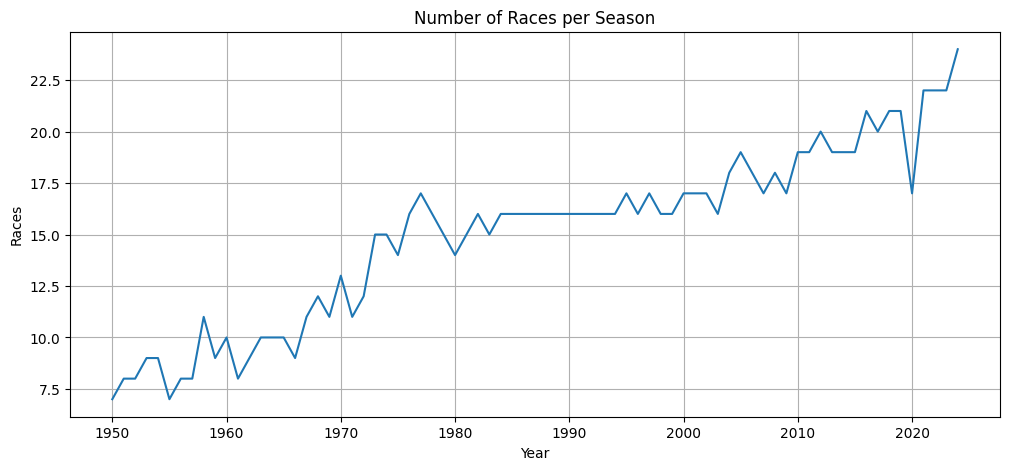

In [ ]:
pdf = yearly_races.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(pdf["year"], pdf["num_races"])
plt.title("Number of Races per Season")
plt.xlabel("Year")
plt.ylabel("Races")
plt.grid(True)
plt.show()

## Driver Performance Analysis

### Top drivers by wins

In [ ]:
top_winners = fact_race_result.filter(F.col("position") == 1) \
    .groupBy("driverId") \
    .agg(F.countDistinct("raceId").alias("wins")) \
    .join(
        drivers.select("driverId", "driver_name"),
        on="driverId",
        how="left"
    ) \
    .select("driver_name", "wins") \
    .orderBy(F.desc("wins"))

top_winners.show(20, truncate=False)

+------------------+----+
|driver_name       |wins|
+------------------+----+
|Lewis Hamilton    |105 |
|Michael Schumacher|91  |
|Max Verstappen    |63  |
|Sebastian Vettel  |53  |
|Alain Prost       |51  |
|Ayrton Senna      |41  |
|Fernando Alonso   |32  |
|Nigel Mansell     |31  |
|Jackie Stewart    |27  |
|Jim Clark         |25  |
|Niki Lauda        |25  |
|Juan Fangio       |24  |
|Nelson Piquet     |23  |
|Nico Rosberg      |23  |
|Damon Hill        |22  |
|Kimi Räikkönen    |21  |
|Mika Häkkinen     |20  |
|Stirling Moss     |16  |
|Jenson Button     |15  |
|Graham Hill       |14  |
+------------------+----+
only showing top 20 rows


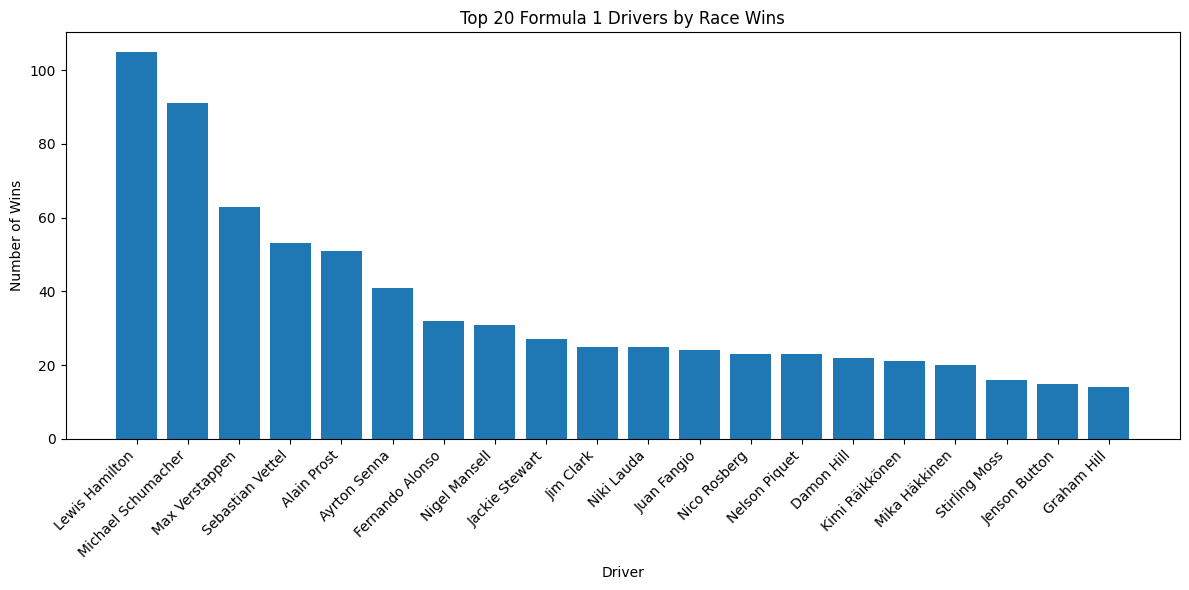

In [ ]:
top_winners_pd = top_winners.limit(20).toPandas()

plt.figure(figsize=(12, 6))
plt.bar(top_winners_pd["driver_name"], top_winners_pd["wins"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Driver")
plt.ylabel("Number of Wins")
plt.title("Top 20 Formula 1 Drivers by Race Wins")
plt.tight_layout()
plt.show()

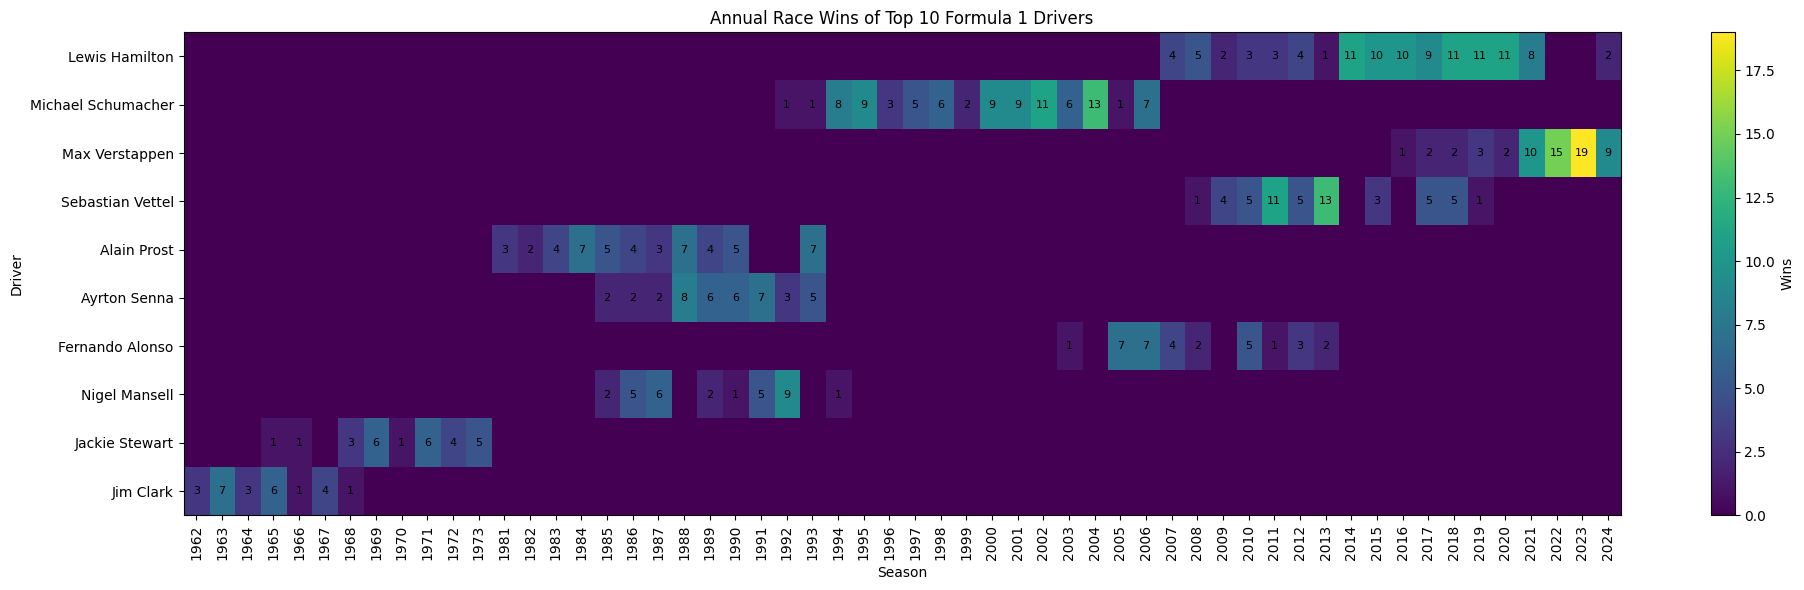

In [ ]:
# Top 10 drivers by total wins
top10_drivers = fact_race_result \
    .filter(F.col("position") == 1) \
    .groupBy("driverId") \
    .agg(F.countDistinct("raceId").alias("total_wins")) \
    .orderBy(F.desc("total_wins")) \
    .limit(10)

# Annual wins for those drivers
yearly_wins = fact_race_result \
    .filter(F.col("position") == 1) \
    .join(top10_drivers.select("driverId"), on="driverId") \
    .groupBy("year", "driverId") \
    .agg(F.countDistinct("raceId").alias("wins"))

# Add driver names
yearly_wins_named = yearly_wins.join(
    drivers.select("driverId", "driver_name"),
    on="driverId",
    how="left"
)

# Convert to Pandas
wins_pd = yearly_wins_named.toPandas()

# Pivot for heatmap
heatmap_data = wins_pd.pivot_table(
    index="driver_name",
    columns="year",
    values="wins",
    fill_value=0
)

# Sort drivers by total wins
heatmap_data = heatmap_data.loc[
    heatmap_data.sum(axis=1).sort_values(ascending=False).index
]

plt.figure(figsize=(20, 6))

im = plt.imshow(
    heatmap_data,
    aspect="auto"
)

plt.colorbar(label="Wins")

# Add numbers inside cells
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]

        if value > 0:
            plt.text(
                j,
                i,
                int(value),
                ha="center",
                va="center",
                fontsize=8
            )

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns,
    rotation=90
)

plt.xlabel("Season")
plt.ylabel("Driver")
plt.title("Annual Race Wins of Top 10 Formula 1 Drivers")

plt.tight_layout()
plt.show()

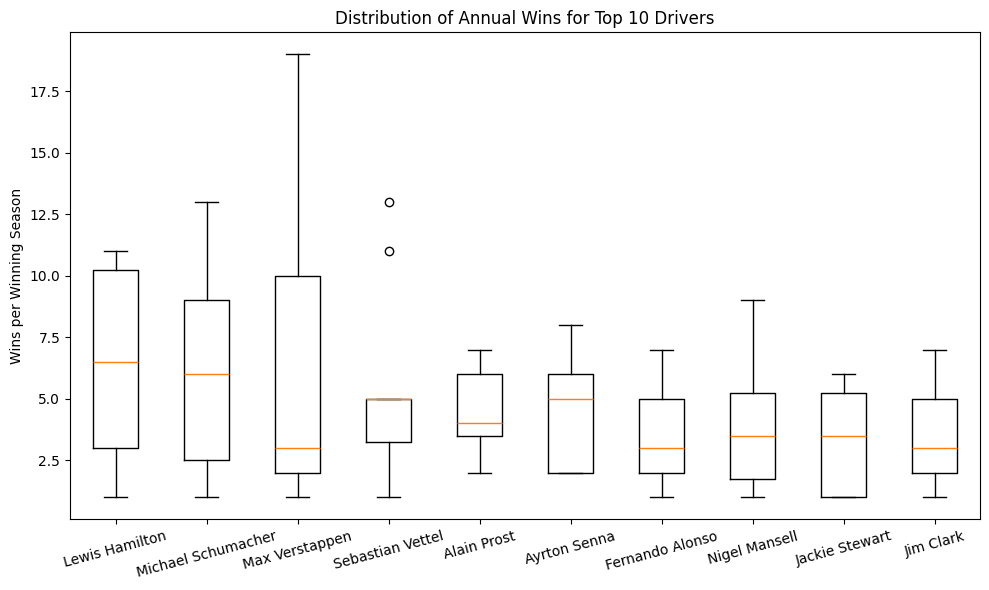

In [ ]:
# Convert to pandas
wins_pd = yearly_wins_named.toPandas()

# Prepare data for boxplot
driver_order = wins_pd.groupby("driver_name")["wins"] \
    .sum() \
    .sort_values(ascending=False) \
    .index

boxplot_data = [
    wins_pd[wins_pd["driver_name"] == driver]["wins"]
    for driver in driver_order
]

# Plot
plt.figure(figsize=(10, 6))

plt.boxplot(
    boxplot_data,
    tick_labels=driver_order
)

plt.ylabel("Wins per Winning Season")
plt.title("Distribution of Annual Wins for Top 10 Drivers")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### Distribution of Annual Wins for Top Drivers

The boxplot compares the distribution of annual race wins among the most successful Formula 1 drivers. Only seasons in which drivers achieved at least one victory were included in the analysis, allowing the comparison to focus on competitive performance rather than career length.

Several important patterns can be observed:

- **Lewis Hamilton** and **Michael Schumacher** demonstrate the highest median number of wins per successful season, indicating long-term consistency and sustained dominance across multiple years.

- **Max Verstappen** shows the largest variability in annual wins, with a very high maximum value reaching 19 wins in a single season. This reflects the exceptional level of dominance achieved during recent Red Bull seasons.

- **Sebastian Vettel** has a relatively compact distribution with several high outliers, suggesting strong peak performance concentrated in specific dominant years.

- **Ayrton Senna**, **Alain Prost**, **Fernando Alonso**, and **Nigel Mansell** exhibit more moderate distributions, reflecting strong performance with fewer exceptionally dominant seasons.

- Older-era drivers such as **Jim Clark** and **Jackie Stewart** generally have lower annual win totals. This is expected because earlier Formula 1 seasons contained significantly fewer races.

Overall, the visualizations highlight both the evolution of Formula 1 across decades and the differences in driver dominance, consistency, and peak performance.

## Data Preprocessing

In [ ]:
# ============================================================
# Gold Layer Construction
# ============================================================
# The Gold layer holds the final analytical tables. They are built
# from the Silver layer using the findings of the missing-value
# analysis above.

if "gold" not in globals():
    gold = {}

# ------------------------------------------------------------
# 1. Race scope: 2004 onwards
# ------------------------------------------------------------
# Timing data becomes reliable from 2004, so the Gold layer keeps
# only races from that season onwards.

races_2004 = (
    silver["races"]
    .filter(F.col("year") >= 2004)
    .select("raceId", "year", "round", "race_name", "date", "circuitId")
)

# ------------------------------------------------------------
# 2. Main fact table: fact_race_results
# ------------------------------------------------------------
# Raw timing columns are dropped:
#   - time, milliseconds, race_duration_ms: total race times are not
#     comparable between drivers (retired and lapped cars).
#   - fastest_lap_ms, fastestLapTime: redundant with fastestLapSpeed;
#     fastestLapTime is a text value and cannot be used numerically.
# fastestLap, rank and fastestLapSpeed are kept. Their empty values
# mark drivers who set no recorded fastest lap, and are handled later
# during modeling.

fact_race_results = (
    silver["results"]
    .join(
        races_2004.select("raceId", "year", "round", "circuitId"),
        on="raceId",
        how="inner"
    )
    # Keep only logically valid fastest-lap records
    .filter(
        (F.col("fastestLap").isNull())
        | (F.col("laps").isNull())
        | (F.col("fastestLap") <= F.col("laps"))
    )
    .drop(
        "time",
        "milliseconds",
        "race_duration_ms",
        "fastest_lap_ms",
        "fastestLapTime"
    )
)

gold["fact_race_results"] = fact_race_results

# ------------------------------------------------------------
# 3. Other fact tables (2004 onwards)
# ------------------------------------------------------------

gold["fact_lap_times"] = (
    silver["lap_times"]
    .join(races_2004.select("raceId"), on="raceId", how="inner")
)

gold["fact_pit_stops"] = (
    silver["pit_stops"]
    .join(races_2004.select("raceId"), on="raceId", how="inner")
)

gold["fact_driver_standings"] = (
    silver["driver_standings"]
    .join(races_2004.select("raceId"), on="raceId", how="inner")
)

gold["fact_constructor_standings"] = (
    silver["constructor_standings"]
    .join(races_2004.select("raceId"), on="raceId", how="inner")
)

# Sprint results: drop the raw timing columns and fill the finishing
# position from positionOrder for drivers who did not finish.
if "sprint_results" in silver:
    gold["fact_sprint_results"] = (
        silver["sprint_results"]
        .join(races_2004.select("raceId"), on="raceId", how="inner")
        .withColumn("position", F.coalesce(F.col("position"), F.col("positionOrder")))
        .drop("time", "milliseconds", "fastestLapTime")
    )

# ------------------------------------------------------------
# 4. Dimension tables
# ------------------------------------------------------------
# Each dimension keeps only the entities that appear in the main
# fact table. The driver dimension drops number and code, which are
# inconsistent across eras.

used_drivers = gold["fact_race_results"].select("driverId").distinct()
used_constructors = gold["fact_race_results"].select("constructorId").distinct()
used_circuits = gold["fact_race_results"].select("circuitId").distinct()
used_races = gold["fact_race_results"].select("raceId").distinct()
used_status = gold["fact_race_results"].select("statusId").distinct()

gold["dim_driver"] = (
    silver["drivers"]
    .drop("number", "code")
    .join(used_drivers, on="driverId", how="left_semi")
)

gold["dim_constructor"] = (
    silver["constructors"]
    .join(used_constructors, on="constructorId", how="left_semi")
)

gold["dim_circuit"] = (
    silver["circuits"]
    .join(used_circuits, on="circuitId", how="left_semi")
)

gold["dim_race"] = (
    races_2004
    .join(used_races, on="raceId", how="left_semi")
)

gold["dim_status"] = (
    silver["status"]
    .join(used_status, on="statusId", how="left_semi")
)

gold["dim_season"] = (
    silver["seasons"]
    .filter(F.col("year") >= 2004)
)

# constructor_results is not included in the Gold layer: its status
# column is almost entirely empty, and the table is largely redundant
# with the race results and constructor standings.

# ------------------------------------------------------------
# 5. Gold layer overview
# ------------------------------------------------------------

for table_name, df in gold.items():
    print(f"{table_name}: {df.count()} rows, {len(df.columns)} columns")

fact_race_results: 8638 rows, 27 columns
fact_lap_times: 456738 rows, 11 columns
fact_pit_stops: 11371 rows, 9 columns
fact_driver_standings: 9150 rows, 9 columns
fact_constructor_standings: 4341 rows, 9 columns
fact_sprint_results: 360 rows, 15 columns
dim_driver: 108 rows, 10 columns
dim_constructor: 35 rows, 7 columns
dim_circuit: 38 rows, 11 columns
dim_race: 412 rows, 6 columns
dim_status: 91 rows, 4 columns
dim_season: 21 rows, 4 columns


In [ ]:
from pyspark.sql import functions as F

# ============================================================
# Gold Layer Validation
# ============================================================

expected_gold_tables = [
    "fact_race_results",
    "fact_lap_times",
    "fact_pit_stops",
    "fact_driver_standings",
    "fact_constructor_standings",
    "fact_sprint_results",
    "dim_driver",
    "dim_constructor",
    "dim_circuit",
    "dim_race",
    "dim_status",
    "dim_season"
]

# ------------------------------------------------------------
# 1. Table presence check
# ------------------------------------------------------------

print("Gold table presence check")

actual_gold_tables = set(gold.keys())

for table in expected_gold_tables:
    print(f"{table}: {'OK' if table in actual_gold_tables else 'MISSING'}")

unexpected_tables = actual_gold_tables - set(expected_gold_tables)

print("\nUnexpected Gold tables:")
print(unexpected_tables if unexpected_tables else "None")


# ------------------------------------------------------------
# 2. Row and column counts
# ------------------------------------------------------------

print("\nGold table sizes")

for table in expected_gold_tables:
    if table in gold:
        print(f"{table}: {gold[table].count()} rows, {len(gold[table].columns)} columns")


# ------------------------------------------------------------
# 3. Year range check for race-linked fact tables
# ------------------------------------------------------------

print("\nYear range check for race-linked fact tables")

race_linked_tables = [
    "fact_race_results",
    "fact_lap_times",
    "fact_pit_stops",
    "fact_driver_standings",
    "fact_constructor_standings",
    "fact_sprint_results"
]

for table in race_linked_tables:
    if table in gold:
        df_with_year = (
            gold[table]
            .join(
                gold["dim_race"].select(
                    F.col("raceId"),
                    F.col("year").alias("race_year")
                ),
                on="raceId",
                how="left"
            )
        )

        print(table)

        df_with_year.agg(
            F.min("race_year").alias("min_year"),
            F.max("race_year").alias("max_year"),
            F.sum(F.when(F.col("race_year").isNull(), 1).otherwise(0)).alias("missing_race_year")
        ).show()


# ------------------------------------------------------------
# 4. Excluded column check
# ------------------------------------------------------------
# Confirms that the columns dropped during Gold construction are
# really absent from the final tables.

print("\nExcluded column check")

excluded_columns_by_table = {
    "fact_race_results": [
        "time",
        "milliseconds",
        "race_duration_ms",
        "fastest_lap_ms",
        "fastestLapTime"
    ],
    "fact_sprint_results": [
        "time",
        "milliseconds",
        "fastestLapTime"
    ],
    "dim_driver": [
        "number",
        "code"
    ]
}

for table, cols in excluded_columns_by_table.items():
    if table in gold:
        existing_excluded = [c for c in cols if c in gold[table].columns]
        print(f"{table}: {'OK' if not existing_excluded else 'STILL PRESENT: ' + str(existing_excluded)}")


# ------------------------------------------------------------
# 5. Missing values check
# ------------------------------------------------------------
# fastestLap, rank and fastestLapSpeed may still contain empty
# values: this marks drivers who set no recorded fastest lap. Those
# are expected. An empty value in any other column is an error.

print("\nMissing values check")

expected_missing = {
    "fact_race_results": ["fastestLap", "rank", "fastestLapSpeed"],
    "fact_sprint_results": ["fastestLap"]
}

for table in expected_gold_tables:
    if table in gold:
        df = gold[table]

        null_counts = df.select([
            F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
            for c in df.columns
        ]).first().asDict()

        allowed = set(expected_missing.get(table, []))

        expected_nulls = {c: n for c, n in null_counts.items() if n > 0 and c in allowed}
        unexpected_nulls = {c: n for c, n in null_counts.items() if n > 0 and c not in allowed}

        print(f"{table}: {'OK' if not unexpected_nulls else 'ERROR'}")

        if expected_nulls:
            print(f"  expected empty values: {expected_nulls}")
        if unexpected_nulls:
            print(f"  UNEXPECTED empty values: {unexpected_nulls}")


# ------------------------------------------------------------
# 6. Duplicate key checks
# ------------------------------------------------------------

print("\nDuplicate key checks")

primary_keys = {
    "dim_driver": ["driverId"],
    "dim_constructor": ["constructorId"],
    "dim_circuit": ["circuitId"],
    "dim_race": ["raceId"],
    "dim_status": ["statusId"],
    "dim_season": ["year"],
    "fact_race_results": ["resultId"],
    "fact_sprint_results": ["resultId"]
}

for table, key_cols in primary_keys.items():
    if table in gold:
        duplicates = (
            gold[table]
            .groupBy(*key_cols)
            .count()
            .filter(F.col("count") > 1)
        )

        print(table)
        duplicates.show(20, truncate=False)


# ------------------------------------------------------------
# 7. Foreign key checks
# ------------------------------------------------------------

print("\nForeign key checks")

def check_fk(child_table, parent_table, child_key, parent_key):
    if child_table not in gold:
        print(f"{child_table}: table missing")
        return

    if parent_table not in gold:
        print(f"{parent_table}: table missing")
        return

    if child_key not in gold[child_table].columns:
        print(f"{child_table}.{child_key} -> {parent_table}.{parent_key}: SKIPPED, child column missing")
        return

    if parent_key not in gold[parent_table].columns:
        print(f"{child_table}.{child_key} -> {parent_table}.{parent_key}: SKIPPED, parent column missing")
        return

    missing_refs = (
        gold[child_table]
        .select(child_key)
        .distinct()
        .join(
            gold[parent_table].select(parent_key).distinct(),
            gold[child_table][child_key] == gold[parent_table][parent_key],
            "left_anti"
        )
    )

    print(f"{child_table}.{child_key} -> {parent_table}.{parent_key}")
    missing_refs.show(20, truncate=False)


# raceId references
for table in race_linked_tables:
    check_fk(table, "dim_race", "raceId", "raceId")

# driverId references
for table in [
    "fact_race_results",
    "fact_lap_times",
    "fact_pit_stops",
    "fact_driver_standings",
    "fact_sprint_results"
]:
    check_fk(table, "dim_driver", "driverId", "driverId")

# constructorId references
for table in [
    "fact_race_results",
    "fact_constructor_standings",
    "fact_sprint_results"
]:
    check_fk(table, "dim_constructor", "constructorId", "constructorId")

# other references
check_fk("fact_race_results", "dim_circuit", "circuitId", "circuitId")
check_fk("fact_race_results", "dim_status", "statusId", "statusId")
check_fk("dim_race", "dim_circuit", "circuitId", "circuitId")
check_fk("dim_race", "dim_season", "year", "year")


# ------------------------------------------------------------
# 8. Invalid value checks
# ------------------------------------------------------------

print("\nInvalid value checks")

def invalid_summary(table, conditions):
    if table not in gold:
        print(f"{table}: table missing")
        return

    print(table)

    gold[table].agg(*[
        F.sum(F.when(cond, 1).otherwise(0)).alias(name)
        for name, cond in conditions.items()
    ]).show(truncate=False)


invalid_summary(
    "fact_race_results",
    {
        "negative_grid": F.col("grid") < 0,
        "negative_position_order": F.col("positionOrder") < 0,
        "negative_points": F.col("points") < 0,
        "negative_laps": F.col("laps") < 0,
        "fastestLap_greater_than_laps": F.col("fastestLap") > F.col("laps")
    }
)

invalid_summary(
    "fact_lap_times",
    {
        "lap_less_than_1": F.col("lap") < 1,
        "position_less_than_1": F.col("position") < 1,
        "negative_lap_time_ms": F.col("lap_time_ms") < 0
    }
)

invalid_summary(
    "fact_pit_stops",
    {
        "stop_less_than_1": F.col("stop") < 1,
        "lap_less_than_1": F.col("lap") < 1,
        "negative_pit_stop_ms": F.col("pit_stop_ms") < 0
    }
)

invalid_summary(
    "fact_driver_standings",
    {
        "negative_points": F.col("points") < 0,
        "position_less_than_1": F.col("position") < 1,
        "negative_wins": F.col("wins") < 0
    }
)

invalid_summary(
    "fact_constructor_standings",
    {
        "negative_points": F.col("points") < 0,
        "position_less_than_1": F.col("position") < 1,
        "negative_wins": F.col("wins") < 0
    }
)

invalid_summary(
    "fact_sprint_results",
    {
        "negative_grid": F.col("grid") < 0,
        "negative_position_order": F.col("positionOrder") < 0,
        "negative_points": F.col("points") < 0,
        "negative_laps": F.col("laps") < 0,
        "fastestLap_greater_than_laps": F.col("fastestLap") > F.col("laps")
    }
)

invalid_summary(
    "dim_circuit",
    {
        "invalid_latitude": (F.col("lat") < -90) | (F.col("lat") > 90),
        "invalid_longitude": (F.col("lng") < -180) | (F.col("lng") > 180)
    }
)

Gold table presence check
fact_race_results: OK
fact_lap_times: OK
fact_pit_stops: OK
fact_driver_standings: OK
fact_constructor_standings: OK
fact_sprint_results: OK
dim_driver: OK
dim_constructor: OK
dim_circuit: OK
dim_race: OK
dim_status: OK
dim_season: OK

Unexpected Gold tables:
None

Gold table sizes
fact_race_results: 8638 rows, 27 columns
fact_lap_times: 456738 rows, 11 columns
fact_pit_stops: 11371 rows, 9 columns
fact_driver_standings: 9150 rows, 9 columns
fact_constructor_standings: 4341 rows, 9 columns
fact_sprint_results: 360 rows, 15 columns
dim_driver: 108 rows, 10 columns
dim_constructor: 35 rows, 7 columns
dim_circuit: 38 rows, 11 columns
dim_race: 412 rows, 6 columns
dim_status: 91 rows, 4 columns
dim_season: 21 rows, 4 columns

Year range check for race-linked fact tables
fact_race_results
+--------+--------+-----------------+
|min_year|max_year|missing_race_year|
+--------+--------+-----------------+
|    2004|    2024|                0|
+--------+--------+--------

### Saving the Gold Tables
All validation checks ran successfully, so the Gold tables are reliable. We can now save them for further use in modeling and graph building

In [40]:
GOLD2_PATH = "/content/lakehouse/gold2"

for table_name, df in gold.items():
    write_parquet(df, f"{GOLD2_PATH}/{table_name}")
    print(f"{table_name}: {df.count()} rows, {len(df.columns)} columns")

fact_race_results: 8638 rows, 27 columns
fact_lap_times: 456738 rows, 11 columns
fact_pit_stops: 11371 rows, 9 columns
fact_driver_standings: 9150 rows, 9 columns
fact_constructor_standings: 4341 rows, 9 columns
fact_sprint_results: 360 rows, 15 columns
dim_driver: 108 rows, 10 columns
dim_constructor: 35 rows, 7 columns
dim_circuit: 38 rows, 11 columns
dim_race: 412 rows, 6 columns
dim_status: 91 rows, 4 columns
dim_season: 21 rows, 4 columns
